# CS4305 Artificial Intelligence — Lab 11
## Expert Systems: Build a "Laptop Doctor"

**What you will learn today**
1. Use **certainty factors (CF)** to deal with uncertain knowledge
2. Build a complete expert system: knowledge base + inference engine + explanations
3. Ask **WHY** a question is asked and see **HOW** a conclusion was reached
4. Use **priorities (salience)** in the CLIPS expert system shell

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _text_tree(ax, children, root, labels, colors=None, gap=1.6, w=1.35, h=0.5, fs=12, level_gap=1.1):
    """Draw a tree whose nodes are text boxes. labels: node-id -> text."""
    colors = colors or {}
    pos = tree_layout(children, root, gap=gap)
    pos = {k: (x, y * level_gap) for k, (x, y) in pos.items()}
    for p, ks in children.items():
        for k in ks:
            (x1, y1), (x2, y2) = pos[p], pos[k]
            ax.plot([x1, x2], [y1 - h / 2, y2 + h / 2], color=GREY, lw=1.8, zorder=1)
    for k, (x, y) in pos.items():
        fc = colors.get(k, PURPLE)
        box(ax, x - w / 2, y - h / 2, w, h, labels.get(k, k), fc=fc, tc=DARK if fc in (ORANGE, LIGHT, WHITE) else WHITE, fs=fs)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - w, max(xs) + w); ax.set_ylim(min(ys) - h * 1.5, max(ys) + h * 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    return pos

ZOO = [("R1", ["has_hair"], "mammal"), ("R2", ["gives_milk"], "mammal"), ("R3", ["has_feathers"], "bird"),
       ("R4", ["mammal", "eats_meat"], "carnivore"), ("R5", ["carnivore", "tawny", "dark_spots"], "cheetah"),
       ("R6", ["carnivore", "tawny", "black_stripes"], "tiger"), ("R7", ["bird", "swims", "cannot_fly"], "penguin")]

NET_POS = {"Animal": (3.5, 4), "Bird": (1.5, 2.4), "Mammal": (5.5, 2.4), "Canary": (0.3, 0.8), "Penguin": (2.7, 0.8),
           "Cow": (5.5, 0.8), "Tweety": (0.3, -0.8), "fly": (-1.2, 2.4), "feathers": (0.4, 3.7), "breathe": (6.9, 4.4),
           "milk": (7.4, 0.8), "yellow": (-1.4, 0.2)}

NET_EDGES = [("Bird", "Animal", "is-a"), ("Mammal", "Animal", "is-a"), ("Canary", "Bird", "is-a"), ("Penguin", "Bird", "is-a"),
             ("Cow", "Mammal", "is-a"), ("Tweety", "Canary", "instance"), ("Bird", "fly", "can"), ("Bird", "feathers", "has"),
             ("Animal", "breathe", "can"), ("Cow", "milk", "gives"), ("Canary", "yellow", "colour")]

def _net(ax, path=None, exception=True):
    concept = {"Animal", "Bird", "Mammal", "Canary", "Penguin", "Cow", "Tweety"}
    on = set(zip(path, path[1:])) if path else set()
    for a, b, lab in NET_EDGES:
        (x1, y1), (x2, y2) = NET_POS[a], NET_POS[b]
        hi = (a, b) in on
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=4 if hi else 1.8,
                    color=ORANGE if hi else GREY, shrinkA=22, shrinkB=22, mutation_scale=16))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, lab, fontsize=10.5, ha="center", va="center", color=DARK,
                bbox=dict(boxstyle="round,pad=0.15", fc=WHITE, ec="none"))
    if exception:
        (x1, y1), (x2, y2) = NET_POS["Penguin"], NET_POS["fly"]
        ax.annotate("", xy=(x2 + 0.3, y2 - 0.2), xytext=(x1 - 0.3, y1 + 0.1), arrowprops=dict(arrowstyle="-|>", lw=2, color=ROSE, ls="--",
                    connectionstyle="arc3,rad=-0.25", shrinkA=14, shrinkB=14))
        ax.text(0.2, 1.55, "can: NO", fontsize=10.5, color=ROSE, fontweight="bold")
    for n_, (x, y) in NET_POS.items():
        if n_ in concept:
            c = ORANGE if n_ == "Tweety" else PURPLE
            box(ax, x - 0.62, y - 0.28, 1.24, 0.56, n_, fc=c, tc=DARK if c == ORANGE else WHITE, fs=11.5)
        else:
            box(ax, x - 0.55, y - 0.25, 1.1, 0.5, n_, fc=LIGHT, tc=DARK, fs=11, bold=False)
    ax.set_xlim(-2.1, 8.1); ax.set_ylim(-1.3, 4.9); ax.set_aspect("equal"); ax.axis("off")
print('Diagram tools ready')

---
## Part 1: The parts of an expert system

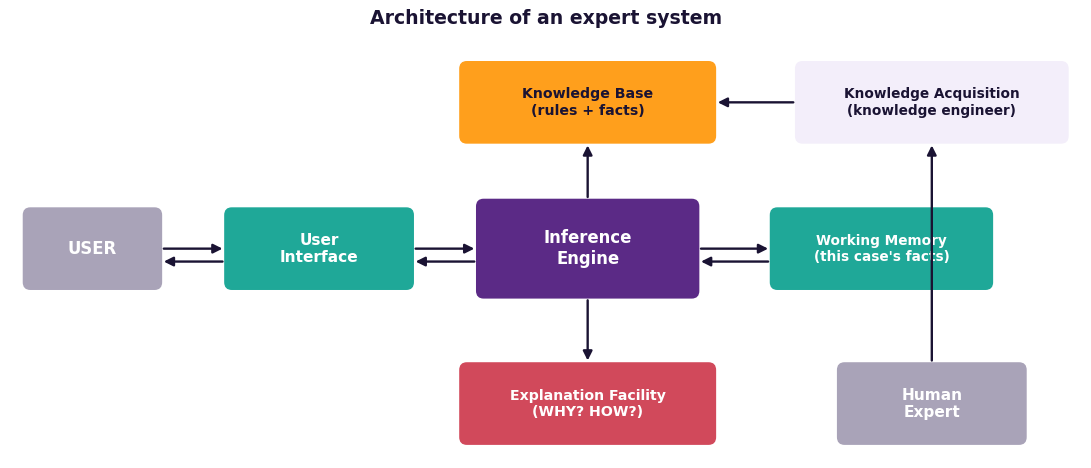

In [ ]:
#@title 📊 Visual explanation: expert system architecture
def fig_es_architecture():
    fig, ax = plt.subplots(figsize=(13, 5.6))
    box(ax, 0.2, 2.3, 1.6, 0.9, "USER", fc=GREY, fs=14)
    box(ax, 2.6, 2.3, 2.2, 0.9, "User\nInterface", fc=TEAL, fs=13)
    box(ax, 5.6, 2.2, 2.6, 1.1, "Inference\nEngine", fc=PURPLE, fs=14)
    box(ax, 5.4, 4.0, 3.0, 0.9, "Knowledge Base\n(rules + facts)", fc=ORANGE, tc=DARK, fs=12)
    box(ax, 9.1, 2.3, 2.6, 0.9, "Working Memory\n(this case's facts)", fc=TEAL, fs=11.5)
    box(ax, 5.4, 0.5, 3.0, 0.9, "Explanation Facility\n(WHY? HOW?)", fc=ROSE, fs=12)
    box(ax, 9.4, 4.0, 3.2, 0.9, "Knowledge Acquisition\n(knowledge engineer)", fc=LIGHT, tc=DARK, fs=11.5)
    box(ax, 9.9, 0.5, 2.2, 0.9, "Human\nExpert", fc=GREY, fs=13)
    for a in [(1.85, 2.75, 2.55, 2.75), (2.55, 2.6, 1.85, 2.6), (4.85, 2.75, 5.55, 2.75), (5.55, 2.6, 4.85, 2.6),
              (6.9, 3.35, 6.9, 3.95), (8.25, 2.75, 9.05, 2.75), (9.05, 2.6, 8.25, 2.6), (6.9, 2.15, 6.9, 1.45),
              (9.35, 4.45, 8.45, 4.45), (11.0, 1.45, 11.0, 3.95)]:
        arrow(ax, *a)
    ax.set_xlim(0, 12.8); ax.set_ylim(0.3, 5.1); ax.axis("off")
    finish(fig, "Architecture of an expert system")
    return fig

fig_es_architecture()
plt.show()

In this lab we build each part ourselves:
| Part | In our code |
|---|---|
| Knowledge base | `RULES`, `QUESTIONS`, `ADVICE` |
| Working memory | `self.known` (answers for this laptop) |
| Inference engine | backward chaining in `cf_of()` |
| Explanation facility | `WHY` (while asking) and `HOW` (in the result) |
| User interface | questions and the diagnosis printout |

---
## Part 2: Certainty factors
Experts are rarely 100% sure. MYCIN used a number from **−1** (definitely false) to **+1** (definitely true).

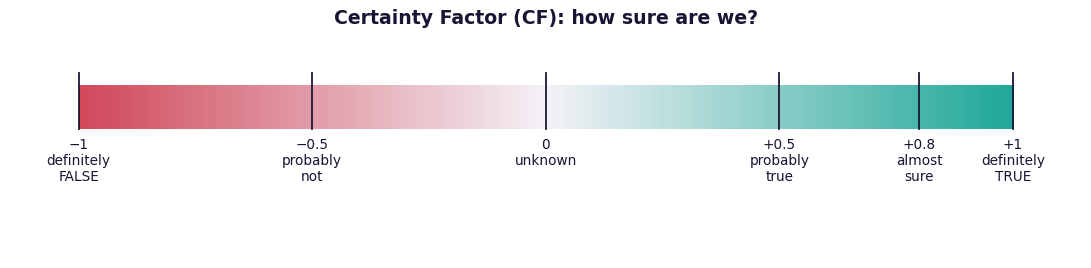

In [ ]:
#@title 📊 Visual explanation: the CF scale
def fig_cf_scale():
    fig, ax = plt.subplots(figsize=(13, 3.2))
    from matplotlib.colors import LinearSegmentedColormap
    cm = LinearSegmentedColormap.from_list("cf", [ROSE, "#F4F2F7", TEAL])
    ax.imshow(np.linspace(0, 1, 300)[None, :], extent=(-1, 1, 0, 0.25), cmap=cm, aspect="auto")
    for v, t in [(-1, "−1\ndefinitely\nFALSE"), (-0.5, "−0.5\nprobably\nnot"), (0, "0\nunknown"), (0.5, "+0.5\nprobably\ntrue"), (0.8, "+0.8\nalmost\nsure"), (1, "+1\ndefinitely\nTRUE")]:
        ax.plot([v, v], [0, 0.32], color=DARK, lw=1.5)
        ax.text(v, -0.05, t, ha="center", va="top", fontsize=11.5, color=DARK)
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-0.75, 0.45); ax.axis("off")
    finish(fig, "Certainty Factor (CF): how sure are we?")
    return fig

fig_cf_scale()
plt.show()

When **two different rules** support the same conclusion, we become **more** sure:
**CF = CF1 + CF2 × (1 − CF1)**

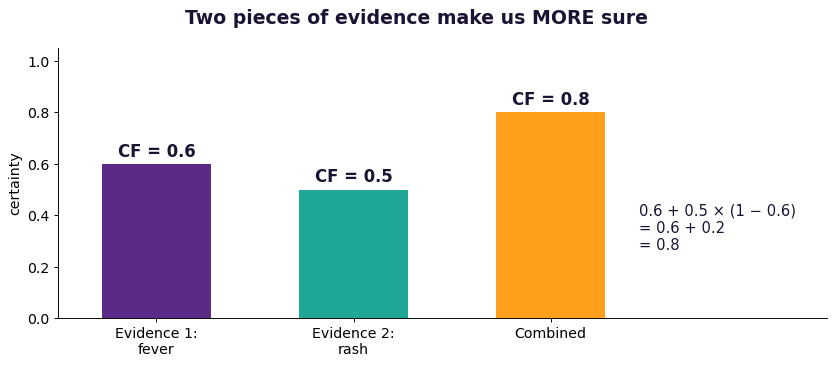

In [ ]:
#@title 📊 Visual explanation: combining evidence
def fig_cf_combine():
    fig, ax = plt.subplots(figsize=(10, 4.4))
    labels = ["Evidence 1:\nfever", "Evidence 2:\nrash", "Combined"]
    vals = [0.6, 0.5, 0.8]
    bars = ax.bar(labels, vals, color=[PURPLE, TEAL, ORANGE], width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.03, f"CF = {v}", ha="center", fontsize=14, fontweight="bold", color=DARK)
    ax.set_ylim(0, 1.05); ax.set_ylabel("certainty", fontsize=12); ax.spines[["top", "right"]].set_visible(False)
    ax.text(2.45, 0.35, "0.6 + 0.5 × (1 − 0.6)\n= 0.6 + 0.2\n= 0.8", fontsize=12.5, color=DARK, va="center")
    ax.set_xlim(-0.5, 3.4)
    finish(fig, "Two pieces of evidence make us MORE sure")
    return fig

fig_cf_combine()
plt.show()

In [ ]:
# ===== Certainty Factors (CF): how sure are we?  -1 = definitely false ... +1 = definitely true =====
def combine(cf1, cf2):
    """Combine two POSITIVE pieces of evidence for the same conclusion (MYCIN formula)."""
    return cf1 + cf2 * (1 - cf1)

print("One reason  (CF 0.6)          :", 0.6)
print("Two reasons (CF 0.6 and 0.5)  :", round(combine(0.6, 0.5), 2))
print("Three reasons (+ CF 0.4)      :", round(combine(combine(0.6, 0.5), 0.4), 2))

# A rule's result = (how sure we are of its IF-part) × (the rule's own CF)
premise = min(0.9, 0.7)        # IF-part: both conditions, so take the weaker one (AND = min)
print("Rule CF 0.8 with premise", premise, "→ conclusion CF =", round(premise * 0.8, 2))

---
## Part 3: The knowledge base
Seven rules from a (pretend) laptop repair expert. Each rule has its own CF.

In [ ]:
# ===== Knowledge base: the "Laptop Doctor" expert system =====
RULES = [
    # name, IF conditions (all must be true), THEN conclusion, rule CF
    ("R1", ["works_only_on_charger"],             "battery_dead",    0.9),
    ("R2", ["no_power_light", "no_charger_light"], "charger_faulty",  0.7),
    ("R3", ["fan_very_loud", "hot_to_touch"],      "overheating",     0.8),
    ("R4", ["shuts_down_suddenly"],                "overheating",     0.5),
    ("R5", ["many_popups", "very_slow"],           "virus",           0.7),
    ("R6", ["very_slow", "clicking_noise"],        "disk_failing",    0.8),
    ("R7", ["beeps_at_startup"],                   "ram_problem",     0.7),
]
QUESTIONS = {
    "works_only_on_charger": "Does the laptop work ONLY when the charger is plugged in?",
    "no_power_light":        "Is the power light OFF when you press the button?",
    "no_charger_light":      "Is the light on the charger OFF?",
    "fan_very_loud":         "Is the fan very loud?",
    "hot_to_touch":          "Is the laptop very hot to touch?",
    "shuts_down_suddenly":   "Does it shut down suddenly?",
    "many_popups":           "Do you see many pop-up adverts?",
    "very_slow":             "Is the laptop very slow?",
    "clicking_noise":        "Do you hear a clicking noise from inside?",
    "beeps_at_startup":      "Does it beep several times when starting?",
}
ADVICE = {
    "battery_dead": "Replace the battery.", "charger_faulty": "Try another charger.",
    "overheating": "Clean the fan and use it on a hard, flat surface.", "virus": "Run an antivirus scan.",
    "disk_failing": "Back up your data NOW and replace the disk.", "ram_problem": "Re-seat or replace the RAM.",
}
print(len(RULES), "rules,", len(QUESTIONS), "possible questions")

---
## Part 4: The inference engine
For each possible problem, the engine finds the rules that conclude it and **asks only the questions it needs**. Answers can be *yes / probably / maybe / no*.

In [ ]:
# ===== The inference engine: backward chaining + CF + WHY/HOW explanations =====
ANSWER_CF = {"yes": 1.0, "probably": 0.6, "maybe": 0.3, "no": -1.0}

class LaptopDoctor:
    def __init__(self, answers=None):
        self.answers = answers          # dict for demo mode, or None to ask with input()
        self.known = {}                 # working memory: fact -> CF
        self.how = {}                   # conclusion -> list of explanations

    def ask(self, fact, rule):
        if fact not in self.known:
            if self.answers is not None:
                reply = self.answers.get(fact, "no")
                print(f"  Q: {QUESTIONS[fact]}  → {reply}")
            else:
                while True:
                    reply = input(f"  Q: {QUESTIONS[fact]} (yes/probably/maybe/no/why) ").strip().lower()
                    if reply == "why":                       # WHY explanation
                        print(f"     WHY: I am testing rule {rule[0]}: IF {' AND '.join(rule[1])} THEN {rule[2]}")
                        continue
                    if reply in ANSWER_CF: break
            self.known[fact] = ANSWER_CF[reply]
        return self.known[fact]

    def cf_of(self, goal):
        if goal in QUESTIONS:
            return None
        total = None
        for rule in RULES:
            name, conds, concl, rule_cf = rule
            if concl != goal:
                continue
            premise = min(self.ask(c, rule) for c in conds)       # AND = weakest condition
            if premise > 0.2:                                     # rule fires only if the IF-part is believed
                cf = premise * rule_cf
                self.how.setdefault(goal, []).append(f"{name} fired (IF {' AND '.join(conds)}) → CF {cf:.2f}")
                total = cf if total is None else combine(total, cf)
        return total or 0.0

    def run(self):
        results = {d: self.cf_of(d) for d in ADVICE}
        print("\n===== DIAGNOSIS =====")
        found = False
        for d, cf in sorted(results.items(), key=lambda x: -x[1]):
            if cf > 0.2:
                found = True
                print(f"{d:15s} CF = {cf:.2f}  →  {ADVICE[d]}")
                for line in self.how[d]:
                    print("      HOW:", line)
        if not found:
            print("No problem found. Please visit a repair shop.")
        return results
print("Inference engine ready.")

### Try it
Two demo laptops with answers given in advance. Look at the **HOW** lines: they explain which rules fired.

In [ ]:
# ===== Demo: a laptop that is hot, loud and switches off =====
LaptopDoctor(answers={"fan_very_loud": "yes", "hot_to_touch": "probably", "shuts_down_suddenly": "yes"}).run();

In [ ]:
# ===== Demo 2: slow laptop with pop-ups =====
LaptopDoctor(answers={"very_slow": "yes", "many_popups": "yes", "clicking_noise": "no"}).run();

### Your turn
Remove the `#` and run. Type **why** at any question to see which rule the system is testing.

In [ ]:
# ===== Your turn: answer the questions yourself (type 'why' to ask the system why) =====
# Remove the # on the next line and run the cell:
# LaptopDoctor().run();

---
## Part 5: The same idea in a real shell (CLIPS)
**Salience** = priority. A rule with higher salience fires first — here the urgent data-loss warning comes before everything else.

In [ ]:
!pip install -q clipspy

In [ ]:
# ===== The same idea in a real expert system shell (CLIPS) with PRIORITY (salience) =====
import clips
env = clips.Environment()
def say(*w): print("".join(str(x) for x in w))
env.define_function(say)

env.build("(deftemplate symptom (slot name))")
env.build("""(defrule overheating (declare (salience 10))
   (symptom (name fan_very_loud)) (symptom (name hot_to_touch))
   => (say "Overheating: clean the fan.") (assert (diagnosis overheating)))""")
env.build("""(defrule disk-danger (declare (salience 50))
   (symptom (name clicking_noise))
   => (say "URGENT: clicking noise - back up your data first!"))""")
env.build("""(defrule done (declare (salience -10))
   (diagnosis ?d) => (say "Case closed. Diagnosis stored: " ?d))""")

for s in ["fan_very_loud", "hot_to_touch", "clicking_noise"]:
    env.assert_string(f"(symptom (name {s}))")
print("Rules fired:", env.run())

---
## 📝 Lab Tasks
1. Add a rule: IF `screen_black` AND `power_light_on` THEN `screen_faulty` (CF 0.7). Add its question and advice. Test it.
2. What CF do you get from three pieces of evidence with CF 0.5 each? Calculate by hand, then with `combine()`.
3. Run the interactive system for a laptop that is **slow** and makes a **clicking noise**. Type **why** for one question.
4. Change the threshold `premise > 0.2` to `0.5`. What changes when you answer *maybe*?
5. **Think:** list two advantages and two limitations of our Laptop Doctor compared with a human technician.